In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# `MiniDINOLoss`의 교차엔트로피 한 줄 뜯어보기

대상 코드는 `MiniDINOLoss.forward` 안의 이 한 줄이다:

```python
loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)
total_loss += loss.mean()
n_terms += 1
...
total_loss /= n_terms
```

원본 [main_dino.py의 `DINOLoss.forward`](../../../main_dino.py#L380)와 글자 단위로 같다
(`n_loss_terms` 이름만 다름). 수식으로는 그냥

$$H(q, p) \;=\; -\sum_{i=1}^{K} q_i \log p_i, \qquad p = \mathrm{softmax}(z_s/\tau_s)$$

인데, **왜 하필 이 형태로 썼는지**가 이 노트북의 주제다. 다루는 것:

1. `log_softmax` vs `log(softmax(...))` — 수치적으로 왜 갈라지는가
2. `-q * log_p` 직접 구현 vs `F.cross_entropy` vs `F.kl_div`
3. `sum(dim=-1)`(클래스 축)과 `.mean()`(배치 축)의 역할 구분
4. `n_terms` 정규화 — crop 수가 늘어도 loss 스케일이 안 변하게
5. gradient가 $(p-q)/\tau_s$ 라는 것 — autograd로 검증
6. 시각화: teacher 분포 $q$가 attractor로 작동하는 그림

In [2]:
import math

import torch
import torch.nn.functional as F
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

torch.manual_seed(0)
torch.set_printoptions(precision=4, sci_mode=False)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. `log_softmax`는 `log(softmax(...))`가 아니다

정의대로 두 단계로 쪼개면 두 번 죽는다.

**(a) 오버플로우** — `exp(z)`를 직접 계산하면 $z \gtrsim 88$에서 float32 `inf`.
`inf/inf = nan`.

**(b) 언더플로우** — `F.softmax` 자체는 안전하지만(내부에서 최댓값을 뺀다),
결과 확률이 $10^{-45}$ 아래면 0으로 뭉개진다. 그 0에 `log`를 씌우면 `-inf`.

`F.log_softmax`는 확률을 만들지 않고 **로그 공간에서 끝까지** 간다:

$$\log \mathrm{softmax}(z)_i \;=\; z_i - m - \log\sum_j e^{z_j - m}, \qquad m = \max_k z_k$$

$m$을 빼서 지수의 최댓값을 $e^0 = 1$로 고정하므로 오버플로우가 없고,
결과가 $-200$ 같은 큰 음수여도 float32가 그대로 표현한다(확률로는 $10^{-87}$이라 표현 불가).

In [3]:
z = torch.tensor([0.0, -100.0, -200.0])          # 확률로는 [1, 3.7e-44, 1.4e-87]
q = torch.tensor([0.5, 0.3, 0.2])                # teacher soft target

# (a) 정의 그대로: exp / sum(exp)  — 로짓을 +100 옮기면 바로 터진다
z_shift = z + 100.0
naive_p = torch.exp(z_shift) / torch.exp(z_shift).sum()

# (b) F.softmax 는 안전하지만, 그 뒤 log 에서 언더플로우가 드러난다
soft_then_log = torch.log(F.softmax(z, dim=-1))

# (c) F.log_softmax
logp = F.log_softmax(z, dim=-1)

# 기준값: float64 log_softmax
ref = F.log_softmax(z.double(), dim=-1)

print("naive exp/sum (z+100) :", naive_p)
print("log(F.softmax(z))     :", soft_then_log)
print("F.log_softmax(z)      :", logp)
print("float64 기준값        :", ref)

naive exp/sum (z+100) : tensor([nan, 0., 0.])
log(F.softmax(z))     : tensor([  0.0000, -99.9831,     -inf])
F.log_softmax(z)      : tensor([   0., -100., -200.])
float64 기준값        : tensor([   0., -100., -200.], dtype=torch.float64)


In [4]:
# 오차 표: 교차엔트로피 -Σ q log p 까지 계산해서 비교
rows = [
    ("exp/sum 직접 (z+100)", torch.log(naive_p)),
    ("log(F.softmax(z))", soft_then_log),
    ("F.log_softmax(z)", logp),
]
true_H = float(torch.sum(-q.double() * ref))
print(f"{'방식':24s} {'log p[2]':>12s} {'H(q,p)':>12s} {'|오차|':>12s}")
for name, lp in rows:
    H = float(torch.sum(-q * lp))
    err = abs(H - true_H)
    print(f"{name:24s} {float(lp[2]):>12.4f} {H:>12.4f} {err:>12.4f}")
print(f"{'float64 기준':24s} {float(ref[2]):>12.4f} {true_H:>12.4f} {0.0:>12.4f}")

방식                           log p[2]       H(q,p)         |오차|
exp/sum 직접 (z+100)               -inf          nan          nan
log(F.softmax(z))                -inf          inf          inf
F.log_softmax(z)            -200.0000      70.0000       0.0000
float64 기준                  -200.0000      70.0000       0.0000


정답은 $H = 0.5\cdot 0 + 0.3\cdot 100 + 0.2\cdot 200 = 70$. 두 단계로 쪼갠 쪽은
`nan` / `inf`를 내고, 그게 그대로 `.backward()`에 흘러 들어가면 파라미터 전체가 `nan`이 된다.

DINO에서 이건 이론적 걱정이 아니다. `out_dim=65536`이라 대부분의 클래스 확률이
$10^{-5}$ 훨씬 아래고, student temp $\tau_s = 0.1$로 **로짓을 10배 키운 뒤** softmax를 하므로
확률 스케일이 극단으로 벌어진다.

In [5]:
# log-sum-exp trick 을 손으로 구현해 F.log_softmax 와 일치하는지 확인
def log_softmax_manual(z):
    m = z.max(dim=-1, keepdim=True).values
    return z - m - torch.log(torch.exp(z - m).sum(dim=-1, keepdim=True))


zz = torch.randn(4, 6) * 30.0          # 스케일 큰 로짓
print("최대 절대 오차:", float((log_softmax_manual(zz) - F.log_softmax(zz, -1)).abs().max()))
print("확률 합(=1 확인):", F.log_softmax(zz, -1).exp().sum(-1))

최대 절대 오차: 0.0
확률 합(=1 확인): tensor([1.0000, 1.0000, 1.0000, 1.0000])


## 2. `-q * log_p` 직접 구현 vs `F.cross_entropy` vs `F.kl_div`

DINO의 target $q$는 **soft**(teacher softmax 출력)다. 지도학습처럼 정수 인덱스가 아니다.
세 API를 비교하면:

| 방식 | 계산하는 값 | soft target |
|---|---|---|
| `torch.sum(-q * F.log_softmax(z), -1)` | $H(q,p)$ | 항상 가능 |
| `F.cross_entropy(z, target)` | $H(q,p)$ | PyTorch ≥ 1.10에서만 |
| `F.kl_div(F.log_softmax(z), q)` | $D_{KL}(q\|p) = H(q,p) - h(q)$ | 가능 |

핵심 항등식:

$$H(q,p) \;=\; \underbrace{h(q)}_{\text{teacher 엔트로피}} + \underbrace{D_{KL}(q\,\|\,p)}_{\text{student가 teacher와 다른 정도}}$$

$q$는 `detach()`되어 있으니 gradient만 보면 `kl_div`와 직접 구현은 **동일**하다.
하지만 **loss 값 자체**는 $h(q)$만큼 다르고, DINO에서 $h(q)$가 줄어드는 경로가
곧 붕괴(collapse)의 통로이므로 로그를 볼 때 이 차이를 알고 있어야 한다.

In [6]:
B, K = 5, 8
z_s = torch.randn(B, K) * 2.0                      # student 로짓 (이미 /τ_s 된 상태라고 치자)
q_soft = F.softmax(torch.randn(B, K) * 3.0, dim=-1)   # teacher soft target

direct = torch.sum(-q_soft * F.log_softmax(z_s, dim=-1), dim=-1).mean()
via_ce = F.cross_entropy(z_s, q_soft)                              # soft label 지원
via_kl = F.kl_div(F.log_softmax(z_s, -1), q_soft, reduction="batchmean")
h_q = (-q_soft * q_soft.clamp_min(1e-12).log()).sum(-1).mean()

print(f"직접 구현            H = {float(direct):.6f}")
print(f"F.cross_entropy      H = {float(via_ce):.6f}   차이 {abs(float(direct-via_ce)):.2e}")
print(f"F.kl_div(batchmean) KL = {float(via_kl):.6f}")
print(f"h(q)                   = {float(h_q):.6f}")
print(f"h(q) + KL              = {float(h_q + via_kl):.6f}  ← H 와 같아야 함")

직접 구현            H = 3.708348
F.cross_entropy      H = 3.708348   차이 2.38e-07
F.kl_div(batchmean) KL = 3.065154
h(q)                   = 0.643194
h(q) + KL              = 3.708348  ← H 와 같아야 함


In [7]:
# hard label(원-핫)일 때는 h(q)=0 이라 셋이 전부 같아진다
idx = torch.tensor([0, 3, 3, 7, 1])
q_hard = F.one_hot(idx, K).float()

print("직접 구현      :", float(torch.sum(-q_hard * F.log_softmax(z_s, -1), -1).mean()))
print("CE(정수 인덱스):", float(F.cross_entropy(z_s, idx)))
print("CE(원-핫 soft) :", float(F.cross_entropy(z_s, q_hard)))
print("KL(batchmean)  :", float(F.kl_div(F.log_softmax(z_s, -1), q_hard, reduction="batchmean")))
print("h(q_hard)      :", float((-q_hard * q_hard.clamp_min(1e-12).log()).sum(-1).mean()))

직접 구현      : 2.7944440841674805
CE(정수 인덱스): 2.7944440841674805
CE(원-핫 soft) : 2.7944440841674805
KL(batchmean)  : 2.7944440841674805
h(q_hard)      : 0.0


즉 DINO가 직접 구현을 쓴 이유는 특별한 수학이 있어서가 아니라,
**2021년 당시 `F.cross_entropy`에 soft label 지원이 없었기 때문**이다.
지금 다시 쓴다면 `F.cross_entropy(student_out[v], q)` 한 줄로 대체 가능하고 값도 동일하다.
(`reduction='none'` + `.mean()` 조합이면 배치 축 평균 시점까지 완전히 같다.)

## 3. `sum(dim=-1)`은 클래스 축, `.mean()`은 배치 축

코드에서 축이 두 번 접힌다:

```python
loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)  # (B,K) → (B,)  클래스 축 K
total_loss += loss.mean()                                             # (B,)  → ()    배치 축 B
```

- 클래스 축은 **반드시 합**: $-\sum_i q_i \log p_i$ 정의 그대로. 평균을 내면 $1/K$ 배가 된다.
- 배치 축은 **반드시 평균**: 배치 크기가 바뀌어도 loss 스케일이 안 변하게.

In [8]:
q2 = F.softmax(torch.randn(B, K) * 2.0, -1)
term = -q2 * F.log_softmax(z_s, dim=-1)
print("term.shape          :", tuple(term.shape))
print("sum(dim=-1).shape   :", tuple(term.sum(dim=-1).shape), " ← 샘플별 교차엔트로피")
print("최종 스칼라          :", float(term.sum(dim=-1).mean()))

term.shape          : (5, 8)
sum(dim=-1).shape   : (5,)  ← 샘플별 교차엔트로피
최종 스칼라          : 3.920689821243286


In [9]:
correct = float(term.sum(dim=-1).mean())              # 올바름
w_mean_class = float(term.mean(dim=-1).mean())        # 클래스 축을 평균 내버림      → 1/K
w_axis_swap = float(term.sum(dim=0).mean())           # 축 뒤바꿈: 배치 합 + 클래스 평균 → B/K
w_mean_sum = float(term.mean(dim=-1).sum())           # 클래스 평균 + 배치 합        → B/K
w_all_mean = float(term.mean())                       # 전부 평균                    → 1/K

print(f"{'계산':42s} {'값':>10s} {'배율':>10s}")
for label, val in [
    ("sum(-1).mean()   ← 올바름", correct),
    ("mean(-1).mean()  ← 클래스 축을 평균", w_mean_class),
    ("sum(0).mean()    ← 축 뒤바뀜", w_axis_swap),
    ("mean(-1).sum()   ← 클래스 평균+배치 합", w_mean_sum),
    ("mean()           ← 전부 평균", w_all_mean),
]:
    print(f"{label:42s} {val:>10.4f} {val/correct:>10.4f}")
print(f"\n1/K = {1/K:.4f},  B/K = {B/K:.4f}  ← 위 배율과 일치 (B={B}, K={K})")

계산                                                  값         배율
sum(-1).mean()   ← 올바름                         3.9207     1.0000
mean(-1).mean()  ← 클래스 축을 평균                   0.4901     0.1250
sum(0).mean()    ← 축 뒤바뀜                       2.4504     0.6250
mean(-1).sum()   ← 클래스 평균+배치 합                 2.4504     0.6250
mean()           ← 전부 평균                       0.4901     0.1250

1/K = 0.1250,  B/K = 0.6250  ← 위 배율과 일치 (B=5, K=8)


배율이 정확히 $1/K$, $B/K$로 떨어지는 게 힌트다. DINO는 $K = 65536$이므로
클래스 축을 실수로 평균 내면 loss가 **65536배 작아지고** gradient도 그만큼 작아져
"학습이 안 되는" 게 아니라 "학습이 6만 배 느려지는" 조용한 버그가 된다.

## 4. `n_terms` 정규화

teacher는 global crop 2개, student는 전체 `ncrops`개를 본다.
같은 view 쌍($v = i_q$)은 건너뛰므로 항의 개수는

$$n_\text{terms} = 2 \times \texttt{ncrops} - 2$$

`total_loss /= n_terms`가 없으면 local crop을 늘릴수록 loss와 gradient가 비례해 커지고,
learning rate를 그때마다 다시 튜닝해야 한다.

In [10]:
def count_terms(ncrops):
    n = 0
    for iq in range(2):                     # teacher: global crop 2개
        for v in range(ncrops):             # student: 전체 crop
            if v == iq:
                continue
            n += 1
    return n


per_term = correct                           # 항 하나의 대표 loss 값 (위 셀에서 계산한 스칼라)
print(f"{'ncrops':>7s} {'n_terms':>8s} {'2*nc-2':>8s} {'정규화 O':>10s} {'정규화 X':>10s}")
for nc in (2, 4, 10):
    n = count_terms(nc)
    print(f"{nc:>7d} {n:>8d} {2*nc-2:>8d} {per_term:>10.4f} {per_term*n:>10.4f}")

 ncrops  n_terms   2*nc-2      정규화 O      정규화 X
      2        2        2     3.9207     7.8414
      4        6        6     3.9207    23.5241
     10       18       18     3.9207    70.5724


DINO 기본 설정은 global 2 + local 8 = `ncrops=10` → **18개 항**이다.
정규화하면 "평균적인 view 쌍 하나의 교차엔트로피"라는 해석 가능한 스케일이 유지된다.

## 5. gradient는 $(p - q)/\tau_s$

코드에서 `student_out[v]`는 이미 $z_s/\tau_s$다. 원본 로짓 $z_s$에 대해 미분하면,
$u = z_s/\tau_s$, $p = \mathrm{softmax}(u)$, $\ell = -\sum_i q_i \log p_i$ 일 때

$$\frac{\partial \ell}{\partial u_j} = p_j - q_j \quad(\textstyle\sum_i q_i = 1),
\qquad \frac{\partial \ell}{\partial z_{s,j}} = \frac{p_j - q_j}{\tau_s}$$

유도는 한 줄이다: $\log p_i = u_i - \log\sum_k e^{u_k}$ 이므로
$\partial \ell / \partial u_j = -q_j + (\sum_i q_i) \, p_j = p_j - q_j$.

**의미**: gradient descent는 $-(p-q)/\tau_s = (q-p)/\tau_s$ 방향으로 로짓을 민다.
student 확률 $p$가 teacher 확률 $q$보다 큰 클래스는 로짓을 내리고, 작은 클래스는 올린다.
즉 **$p$를 $q$ 쪽으로 곧장 끌어당기는 힘**이고, $\tau_s$가 작을수록 그 힘이 $1/\tau_s$ 배 세진다.

In [11]:
tau_s = 0.1
B2, K2 = 4, 6
z_raw = (torch.randn(B2, K2) * 1.5).requires_grad_(True)
q_t = F.softmax(torch.randn(B2, K2) * 2.0, -1).detach()

# MiniDINOLoss 안의 그 한 줄 그대로 (배치 평균까지)
student_out = z_raw / tau_s
loss = torch.sum(-q_t * F.log_softmax(student_out, dim=-1), dim=-1).mean()
loss.backward()

p = F.softmax(z_raw.detach() / tau_s, dim=-1)
analytic = (p - q_t) / tau_s / B2          # .mean() 때문에 배치 크기로 한 번 더 나뉜다

print("loss           :", float(loss))
print("autograd grad[0]:", z_raw.grad[0])
print("(p-q)/τ/B  [0]  :", analytic[0])
print("최대 절대 오차   :", float((z_raw.grad - analytic).abs().max()))
print("grad 행 합(≈0)  :", z_raw.grad.sum(-1))

loss           : 23.860841751098633
autograd grad[0]: tensor([ 0.9276, -0.0891, -0.0120, -0.4309, -0.3481, -0.0474])
(p-q)/τ/B  [0]  : tensor([ 0.9276, -0.0891, -0.0120, -0.4309, -0.3481, -0.0474])
최대 절대 오차   : 2.980232238769531e-07
grad 행 합(≈0)  : tensor([     0.0000,     -0.0000,      0.0000,     -0.0000])


두 가지가 확인된다:

- autograd와 해석식이 $10^{-8}$ 수준(float32 epsilon)에서 일치
- **각 행의 gradient 합이 0** — $\sum_j (p_j - q_j) = 1 - 1 = 0$이므로 당연하다.
  gradient가 확률 단순체(simplex)의 접평면 안에 살고 있다는 뜻이고,
  덕분에 아래 그림에서 화살표를 단순체 평면 위에 그대로 그릴 수 있다.

In [12]:
# τ_s 를 바꿔가며 gradient 크기가 정확히 1/τ_s 로 스케일되는지 확인
print(f"{'τ_s':>6s} {'‖grad‖':>12s} {'‖p-q‖/B':>12s} {'비율':>12s}")
base = None
for t in (1.0, 0.5, 0.2, 0.1, 0.04):
    zz2 = z_raw.detach().clone().requires_grad_(True)
    L = torch.sum(-q_t * F.log_softmax(zz2 / t, dim=-1), dim=-1).mean()
    L.backward()
    g = float(zz2.grad.norm())
    d = float(((F.softmax(zz2.detach() / t, -1) - q_t) / B2).norm())
    print(f"{t:>6.2f} {g:>12.4f} {d:>12.4f} {g/d:>12.2f}")

   τ_s       ‖grad‖      ‖p-q‖/B           비율
  1.00       0.3514       0.3514         1.00
  0.50       0.8233       0.4116         2.00
  0.20       2.2467       0.4493         5.00
  0.10       4.5973       0.4597        10.00
  0.04      11.6534       0.4661        25.00


비율이 정확히 $1/\tau_s$다. DINO 기본값 $\tau_s = 0.1$은 gradient를 10배 증폭한다는 뜻이고,
이게 student temp를 teacher temp(0.04)보다 크게 잡는 이유 중 하나다 —
더 작게 하면 gradient가 25배로 튀어 학습이 불안정해진다.

## 6. 시각화 — teacher 분포가 attractor다

$K=3$이면 확률 분포 전체를 삼각형(2-단순체) 위에 그릴 수 있다.
각 격자점 $p$에서 descent 방향 $-(p-q)/\tau_s = (q-p)/\tau_s$ 화살표를 그리면,
모든 화살표가 $q$ 한 점을 가리킨다. 오른쪽 패널은 $\tau_s$에 따른 크기 스케일링.

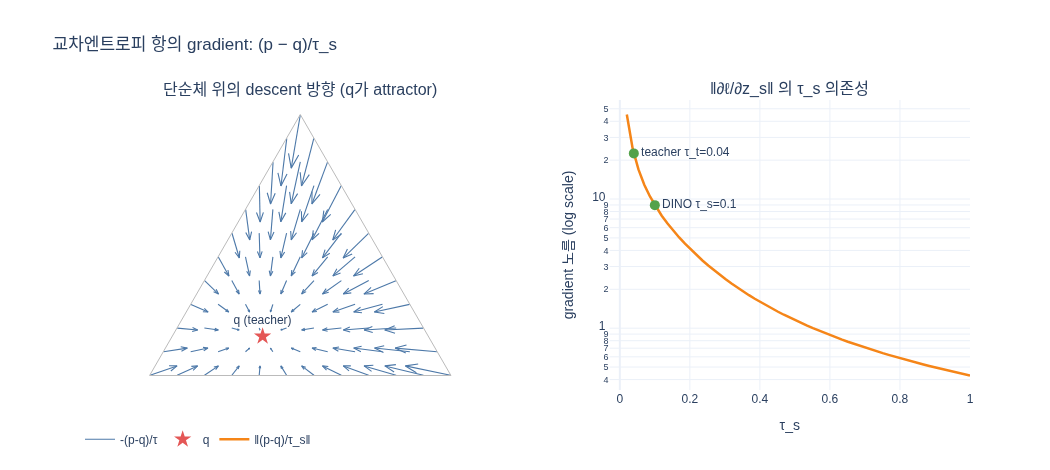

expy.png 저장 완료


In [13]:
SQ3 = math.sqrt(3.0) / 2.0


def to_xy(p):
    """단순체 좌표 (p0,p1,p2) → 2D 삼각형 좌표"""
    return p[..., 1] + 0.5 * p[..., 2], SQ3 * p[..., 2]


q_star = torch.tensor([0.55, 0.30, 0.15])       # 고정된 teacher 분포
tau_vis = 0.5                                    # 화살표가 보이도록 τ 를 크게

xs, ys, us, vs = [], [], [], []
n_grid = 11
for i in range(n_grid + 1):
    for j in range(n_grid + 1 - i):
        k = n_grid - i - j
        p_pt = torch.tensor([i, j, k], dtype=torch.float32) / n_grid
        p_pt = p_pt.clamp_min(1e-3)
        p_pt = p_pt / p_pt.sum()
        g = (q_star - p_pt) / tau_vis            # descent 방향
        x, y = to_xy(p_pt)
        gx, gy = to_xy(g + p_pt)                 # 벡터도 같은 선형변환을 통과
        x0, y0 = to_xy(p_pt)
        xs.append(float(x)); ys.append(float(y))
        us.append(float(gx - x0)); vs.append(float(gy - y0))

quiv = ff.create_quiver(xs, ys, us, vs, scale=0.12, arrow_scale=0.28,
                        line=dict(width=1.1, color="#4c78a8"), name="-(p-q)/τ")

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("단순체 위의 descent 방향 (q가 attractor)",
                    "‖∂ℓ/∂z_s‖ 의 τ_s 의존성"),
    column_widths=[0.55, 0.45],
)
for tr in quiv.data:
    fig.add_trace(tr, row=1, col=1)

# 삼각형 테두리
corners = torch.eye(3)
cx, cy = to_xy(corners)
fig.add_trace(go.Scatter(x=list(cx.numpy()) + [float(cx[0])],
                         y=list(cy.numpy()) + [float(cy[0])],
                         mode="lines", line=dict(color="#bbb", width=1),
                         showlegend=False), row=1, col=1)
qx, qy = to_xy(q_star)
fig.add_trace(go.Scatter(x=[float(qx)], y=[float(qy)], mode="markers+text",
                         marker=dict(size=13, color="#e45756", symbol="star"),
                         text=["q (teacher)"], textposition="top center",
                         name="q"), row=1, col=1)

# 오른쪽: gradient 크기 vs τ_s
taus = torch.linspace(0.02, 1.0, 60)
p_fix = torch.tensor([0.2, 0.5, 0.3])
z_fix = p_fix.log()                              # 이 로짓이 τ=1에서 p_fix 를 만든다
norms = []
for t in taus:
    pt = F.softmax(z_fix / t, dim=-1)
    norms.append(float(((pt - q_star) / t).norm()))
fig.add_trace(go.Scatter(x=taus.numpy(), y=norms, mode="lines",
                         line=dict(color="#f58518", width=2.5),
                         name="‖(p-q)/τ_s‖"), row=1, col=2)
for t_mark, lbl in ((0.1, "DINO τ_s=0.1"), (0.04, "teacher τ_t=0.04")):
    pt = F.softmax(z_fix / t_mark, dim=-1)
    fig.add_trace(go.Scatter(x=[t_mark], y=[float(((pt - q_star) / t_mark).norm())],
                             mode="markers+text", marker=dict(size=10, color="#54a24b"),
                             text=[lbl], textposition="middle right",
                             showlegend=False), row=1, col=2)

fig.update_xaxes(visible=False, row=1, col=1)
fig.update_yaxes(visible=False, scaleanchor="x", scaleratio=1, row=1, col=1)
fig.update_xaxes(title_text="τ_s", row=1, col=2)
fig.update_yaxes(title_text="gradient 노름 (log scale)", type="log", row=1, col=2)
fig.update_layout(width=1050, height=470, template="plotly_white",
                  title_text="교차엔트로피 항의 gradient: (p − q)/τ_s",
                  legend=dict(orientation="h", y=-0.12))

fig.write_image("expy.png", scale=2)
_show(fig)
print("expy.png 저장 완료")

왼쪽 그림: 단순체 어디에서 출발해도 화살표는 빨간 별($q$)을 향한다.
$q$는 `detach()`되어 있으므로 이 항만 보면 **teacher가 고정된 목표점**이고,
student는 그쪽으로 끌려간다. (실제 DINO에서 $q$ 자체가 student의 EMA를 따라 움직이기 때문에
목표점이 도망갈 수 있고, 그래서 centering/sharpening이 필요하다.)

오른쪽 그림: $\tau_s$가 작아질수록 gradient 노름이 대략 $1/\tau_s$로 커진다
(분자 $\|p-q\|$도 같이 변하지만 1로 유계라 $1/\tau_s$가 지배한다).

## 요약

```python
loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)
```

| 조각 | 이유 |
|---|---|
| `F.log_softmax` | log-sum-exp로 오버/언더플로우 회피. `log(softmax(...))`는 `-inf`/`nan` |
| `-q * ...` | $q$가 soft target이라 2021 당시 `F.cross_entropy`로는 표현 불가 |
| `sum(dim=-1)` | 클래스 축 $K$를 정의대로 **합** (평균 내면 $1/K$ 배) |
| `.mean()` | 배치 축 $B$를 평균 — 배치 크기 독립 |
| `/= n_terms` | $2\cdot\texttt{ncrops}-2$개 항의 평균 — crop 수 독립 |
| gradient | $(p-q)/\tau_s$ — student를 teacher 쪽으로 미는 힘, $1/\tau_s$로 증폭 |